<a href="https://colab.research.google.com/github/praveen2007kiet-crypto/MUSICAL-INSTRUMENTS-FREQUENCY-ANALYZER-/blob/main/Sample_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simple inputs
mass = 1.0       # mass of each object (kg)
spring = 100.0   # spring stiffness (N/m)

print("Mass =", mass, "kg")
print("Spring stiffness =", spring, "N/m")

Mass = 1.0 kg
Spring stiffness = 100.0 N/m


In [3]:
# Mass matrix
M = mass * np.eye(3)

# Stiffness matrix
K = spring * np.array([
    [2, -1,  0],
    [-1, 2, -1],
    [0, -1,  2]
])

print("Mass matrix M:")
print(M)

print("\nStiffness matrix K:")
print(K)

Mass matrix M:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Stiffness matrix K:
[[ 200. -100.    0.]
 [-100.  200. -100.]
 [   0. -100.  200.]]


In [4]:
# Convert the generalized problem K v = lambda M v
A = np.linalg.inv(M) @ K

# Find eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Sort from smallest to largest
order = np.argsort(eigenvalues)

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Natural frequencies
frequencies = np.sqrt(eigenvalues) / (2 * np.pi)

print("Eigenvalues:")
print(eigenvalues)

print("\nNatural frequencies (Hz):")
print(frequencies)

Eigenvalues:
[ 58.57864376 200.         341.42135624]

Natural frequencies (Hz):
[1.2181192  2.25079079 2.94079989]


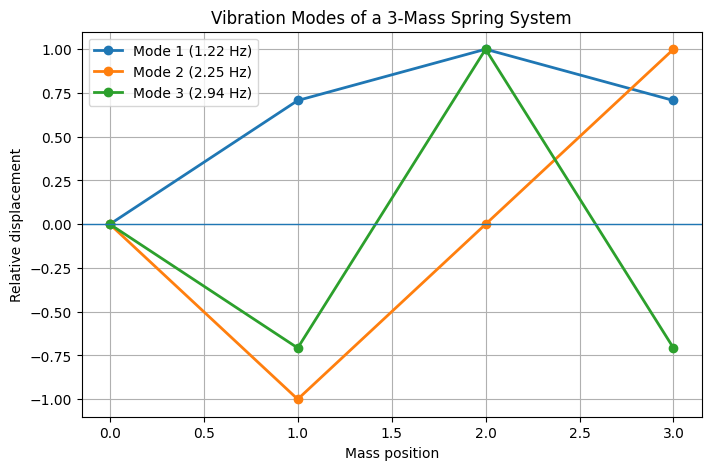

In [5]:
x = np.array([0, 1, 2, 3])

plt.figure(figsize=(8, 5))

for i in range(3):
    mode = np.insert(eigenvectors[:, i], 0, 0)

    # Normalize the mode
    mode = mode / np.max(np.abs(mode))

    plt.plot(x, mode, marker='o', linewidth=2,
             label=f"Mode {i+1} ({frequencies[i]:.2f} Hz)")

plt.axhline(0, linewidth=1)
plt.xlabel("Mass position")
plt.ylabel("Relative displacement")
plt.title("Vibration Modes of a 3-Mass Spring System")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
from ipywidgets import interact, FloatSlider

def analyze(mass, spring):

    M = mass * np.eye(3)

    K = spring * np.array([
        [2, -1, 0],
        [-1, 2, -1],
        [0, -1, 2]
    ])

    A = np.linalg.inv(M) @ K

    eigenvalues, eigenvectors = np.linalg.eig(A)

    order = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    frequencies = np.sqrt(eigenvalues) / (2 * np.pi)

    print("Natural frequencies:")
    for i, f in enumerate(frequencies):
        print(f"Mode {i+1}: {f:.2f} Hz")

    x = np.array([0, 1, 2, 3])

    plt.figure(figsize=(8, 5))

    for i in range(3):
        mode = np.insert(eigenvectors[:, i], 0, 0)
        mode = mode / np.max(np.abs(mode))

        plt.plot(
            x, mode,
            marker='o',
            linewidth=2,
            label=f"Mode {i+1}"
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("Mass position")
    plt.ylabel("Relative displacement")
    plt.title("Vibration Mode Shapes")
    plt.grid(True)
    plt.legend()
    plt.show()


interact(
    analyze,
    mass=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5),
    spring=FloatSlider(value=100, min=20, max=300, step=20)
);

interactive(children=(FloatSlider(value=1.0, description='mass', max=5.0, min=0.5, step=0.5), FloatSlider(valu…